In [1]:
import os
import kagglehub

os.environ["KAGGLE_API_TOKEN"] = "PRIVATE"

# 다운로드할 캐글 데이터셋 '소유자/데이터셋명' 입력
DATA = kagglehub.dataset_download("kmader/siim-medical-images")
print("다운로드 경로:", DATA)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 250M/250M [00:09<00:00, 28.5MB/s]

Extracting files...


다운로드 경로: C:\Users\301-16\.cache\kagglehub\datasets\kmader\siim-medical-images\versions\6


In [9]:
import os, glob
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

In [8]:
dicom_files = sorted(glob.glob(os.path.join(DATA, '**', '*.dcm'), recursive=True))
print(f'DICOM{len(dicom_files)}장')
print(f'file name rule :{os.path.basename(dicom_files[0])}')

DICOM100장
file name rule :ID_0000_AGE_0060_CONTRAST_1_CT.dcm


In [12]:
ds = pydicom.dcmread(dicom_files[0])
print('ct mata data')
for tag in ['Rows', 'Columns', 'BitsStored', 'PixelRepresentation']:
    #Height and Width (in pixels) 12bit(0-4095) Truncated when read as 8bit 0 = Unsigned +-
    print(f'{tag:24} {getattr(ds, tag,"-")}')
for tag in ['RescaleSlope', 'RescaleIntercept', 'PixelSpacing']:
    #HU transform must need
    print(f'{tag:24}  {getattr(ds, tag, "-")}')

ct mata data
Rows                     512
Columns                  512
BitsStored               12
PixelRepresentation      0
RescaleSlope              001.000000E+00
RescaleIntercept          -01.024000E+03
PixelSpacing              [007.812500e-01, 007.812500e-01]


In [ ]:
for tag in ['KVP', 'XRayTubeCurrent', 'Convolutionkernel', 'Manufacturer']:
    # Higher kVp reduces noise; higher mA improves clarity but increases radiation dose.
    # # Different reconstruction kernels change texture, affecting model performance consistency.
    # Manufacturer (Main driver of domain gap)
    print(f'{tag:24}  {getattr(ds, tag, "-")}')

In [14]:
# pixel_array contains raw stored values, not HU values, and needs conversion.
# HU = pixel_array * RescaleSlope + RescalIntercept
# Intercept = -1024; without it, air is displayed as 0
raw = ds.pixel_array
hu = raw*ds.RescaleSlope + ds.RescaleIntercept
print(f'raw stored value {raw.dtype} {raw.min()} - {raw.max()}')
print(f'HU conversion {hu.dtype} {hu.min():.0f} - {hu.max():.0f}')

raw stored value uint16 0 - 1918
HU conversion float64 -1024 - 894


In [16]:
print('HU-based tissue verification') # water = 0, air =-1000
for name, low, high in [('Air', -1100, -900), 
                       ('Lung Parenchyma', -900, -500), # Air + Tissue => Intermediate / Mixed value
                       ('Fat', -150, -30), # Less attenuation than water (-)
                       ('Soft Tissue', 20, 80),# Muscle and organs; increases with contrast agent
                       ('Bone', 300, 2000)]:# Higher calcium attenuation
    ratio = np.mean((hu >= low)&(hu <= high))
    print(f'{name:8}({low:5}-{high:5} HU) {ratio:6.1%}')

HU-based tissue verification
Air     (-1100- -900 HU)  49.7%
Lung Parenchyma( -900- -500 HU)  25.6%
Fat     ( -150-  -30 HU)   7.4%
Soft Tissue(   20-   80 HU)   6.4%
Bone    (  300- 2000 HU)   1.6%


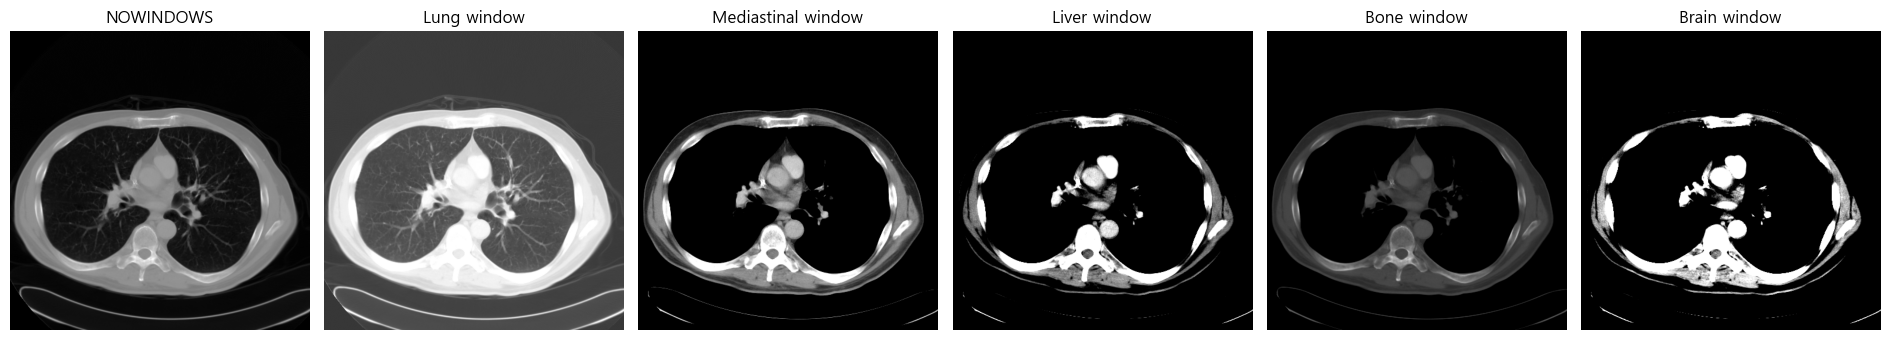

In [18]:
def apply_window(hu_array, center, width):
    low, high = center - width /2, center +width /2
    return ((np.clip(hu_array, low, high)-low)/(high - low)* 255).astype(np.uint8)
WINDOWS = [('Lung window', -600, 1500),
          ('Mediastinal window', 40, 400),
          ('Liver window', 60, 150),
          ('Bone window', 400, 1500),
          ('Brain window', 40, 80)]
fig, axes = plt.subplots(1, len(WINDOWS)+ 1, figsize=(19, 3.6))
axes[0].imshow(hu, cmap='gray'); axes[0].set_title('NOWINDOWS'); axes[0].axis('off')
for ax, (name, c, w) in zip(axes[1:], WINDOWS):
    ax.imshow(apply_window(hu, c, w), cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{name}'); ax.axis('off')
plt.tight_layout(); plt.show()